In [1]:
from utilities import DataSimulator, prepare_data,plot_learning_curve, analyze_error_distribution, ks_test_gan_cdf,plot_bin_dist 
from myCGAN import MyCGAN
from myCWGAN import MyCWGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

In [ ]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

In [ ]:
print(file_paths)
print(file_pdf)

# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'mean_std_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

# BINS DISTRIBUTION PROBABILITIES 1


In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, verbose=True)
pdfs

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_p_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_p_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
summary

## ks test 

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=1

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100)
bins = val.bins

In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.load_models()

In [4]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)


In [ ]:
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df

In [ ]:
generated_sample = generated[0]
true_sample = pdfs[0]

plot_bin_dist(true_sample, generated_sample, bins)



# BINS DISTRIBUTION PROBABILITIES 2


In [ ]:
# data simulation 
# example
X0_range = (-1.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 0.5)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
sim.save_configuration('./models/bins/CGAN_bins_pglobal.json')
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=200, name='CGAN_bins_pglobal')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_pglobal_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_pglobal_error_dist.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [6]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]#[0.8, -0.8, 0.0, 0.2, -0.2]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.001, 0.01, 0.05, 0.1, 0.5, 0.8]
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_bins_pglobal.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=10)
Xt = val.X_T
bins = val.bins



Bins loaded from models\bins\CGAN_bins_pglobal.json
Loaded 101 bins


In [7]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_pglobal')
conditional_gan.load_models()

CGAN config loaded from ./models\CGAN_bins_pglobal_config.json
Generator loaded from ./models\CGAN_bins_pglobal_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [128, 256, 128], 'is_prob': True, 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\CGAN_bins_pglobal_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [256, 128], 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [8]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df


,p_values
0,2.676102e-12
1,4.812613e-19
2,1.291781e-12
3,4.994212e-03
4,8.291755e-33
5,1.251677e-13


In [27]:
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))
test_h0

0.0


,p_values


In [5]:
Xt

array([-1.58906936e-04, -1.62955883e-02, -1.64102985e-02,  5.13571998e-02,
       -1.47264368e+00])

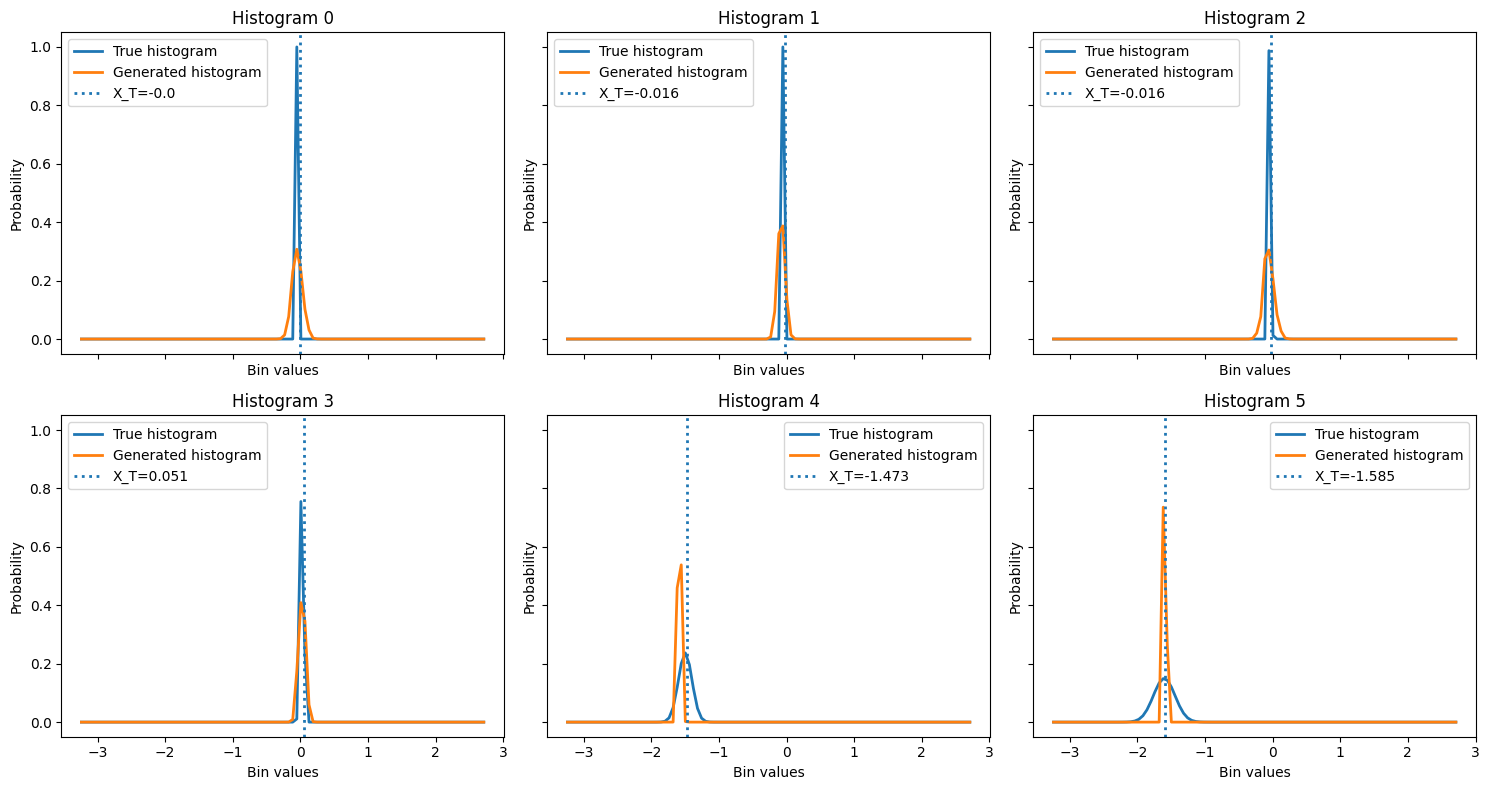

In [11]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# CWGAN BINS PROBABILITIES

In [2]:
# data simulation 
# example
X0_range = (-1.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 0.5)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
sim.save_configuration('./models/bins/CWGAN_bins_pglobal.json')
pdfs

Bins saved to models\bins\CWGAN_bins_pglobal.json


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100000, 100))

In [3]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCWGAN(max_epoch=200, name='CWGAN_bins_pglobal')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=10)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'CWGAN_error_dist.csv')


Epoch: 0/200, Step: 0, C_loss: 8.3784, G_loss: -0.4133, W_dist: 0.7619, GP: 0.9140
Epoch: 0/200, Step: 500, C_loss: -560.7177, G_loss: -468.4736, W_dist: 995.2561, GP: 43.4538
Epoch: 0/200, Step: 1000, C_loss: -471.5447, G_loss: -506.9763, W_dist: 833.9731, GP: 36.2428
Epoch: 0/200, Step: 1500, C_loss: -401.9381, G_loss: -510.9438, W_dist: 698.3633, GP: 29.6425


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\myCWGAN.py:366: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  C_loss_list.append(round(float(C_loss), 4))


Epoch: 0/200, Step: 2000, C_loss: -351.7837, G_loss: -506.7763, W_dist: 586.7572, GP: 23.4974
Epoch: 0/200, Step: 2500, C_loss: -267.8698, G_loss: -491.2077, W_dist: 446.9881, GP: 17.9118
Epoch: 0/200, Step: 3000, C_loss: -188.8333, G_loss: -487.2878, W_dist: 319.5994, GP: 13.0766
Epoch: 1/200, Step: 3500, C_loss: -143.3077, G_loss: -416.5881, W_dist: 233.0876, GP: 8.9780
Epoch: 1/200, Step: 4000, C_loss: -95.0251, G_loss: -339.0706, W_dist: 153.3147, GP: 5.8290
Epoch: 1/200, Step: 4500, C_loss: -75.7735, G_loss: -299.3207, W_dist: 112.9497, GP: 3.7176
Epoch: 1/200, Step: 5000, C_loss: -46.8648, G_loss: -148.4324, W_dist: 68.2309, GP: 2.1366
Epoch: 1/200, Step: 5500, C_loss: -55.7921, G_loss: -19.5432, W_dist: 74.7096, GP: 1.8918
Epoch: 1/200, Step: 6000, C_loss: -44.4824, G_loss: -51.8846, W_dist: 61.7885, GP: 1.7306

📊 Epoch 1 Summary:
   Avg W-distance: 68.9833
   Epoch time: 18.15s
  → New best W-distance: 68.9833
Epoch: 2/200, Step: 6500, C_loss: -35.7584, G_loss: 12.3110, W_dist: